### Implemented Reinforce without baseline
1. for discrete action space using softmax at the end of policy netowrk
2. normalizing the returns for reducing variace a bit

In [1]:
!pip install -r ../requirements.txt

In [2]:
import sys
import importlib
import numpy as np
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.reinforce as reinforce
import configurations.config_p1_sub6 as config_path

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(reinforce)
importlib.reload(config_path)

device used:  cuda
device used:  cuda


<module 'configurations.config_p1_sub6' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p1_sub6.py'>

In [3]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.reinforce import Reinforce
from configurations.config_p1_sub6 import config

In [4]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=0,
    box_speed=2
)
reinforceAgent = Reinforce(env, **config)

In [5]:
print(config)

{'seed': 333, 'gamma': 0.999, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.001, 'MAX_TRAIN_EPISODES': 200, 'MAX_EVAL_EPISODES': 5, 'explorationStrategyTrainFn': <function selectPolicyAction at 0x0000024255DDE050>, 'explorationStrategyEvalFn': <function selectPolicyGreedyAction at 0x0000024255DDE0E0>, 'device': device(type='cuda'), 'hDim': [128, 64], 'model_path': '../model_weights_phase1_sub6'}


In [6]:
ReinforceTrainRewardsList, ReinforceTrainTimeList, ReinforceEvalRewardsList, ReinforceWallClockTimeList, ReinforceTotalStepsList, ReinforceFinalEvalReward = reinforceAgent.runREINFORCE()

Episode 0: TR -30000.0 | ER -114093.4 | TT 9.859123229980469 | WC 35.295674085617065 | TS 1000
Episode 1: TR -989.0 | ER -191879.0 | TT 45.25849652290344 | WC 86.35607862472534 | TS 1000
Episode 2: TR -972.0 | ER -157903.4 | TT 96.06131672859192 | WC 128.25393295288086 | TS 1000
Episode 3: TR -12400.0 | ER -192317.6 | TT 138.26213812828064 | WC 179.66651129722595 | TS 1000
Episode 4: TR -55200.0 | ER -192280.0 | TT 189.6247570514679 | WC 232.65490984916687 | TS 1000
Episode 5: TR -14400.0 | ER -193999.0 | TT 242.28442239761353 | WC 283.4762213230133 | TS 1000
Episode 6: TR -69400.0 | ER -192396.8 | TT 293.5738744735718 | WC 335.3415515422821 | TS 1000
Episode 7: TR -972.0 | ER -191719.2 | TT 345.1390755176544 | WC 386.99025797843933 | TS 1000
Episode 8: TR -1000.0 | ER -196579.8 | TT 397.2209060192108 | WC 438.91780614852905 | TS 1000
Episode 9: TR -27600.0 | ER -157340.4 | TT 449.25738048553467 | WC 481.7773013114929 | TS 1000
Episode 10: TR -15600.0 | ER -154148.4 | TT 491.9562578201

In [7]:
print(f"Reinforce Final Evaluation Reward: {ReinforceFinalEvalReward[0]} +- {ReinforceFinalEvalReward[1]}")

Reinforce Final Evaluation Reward: -151271.8 +- 76909.38408386847


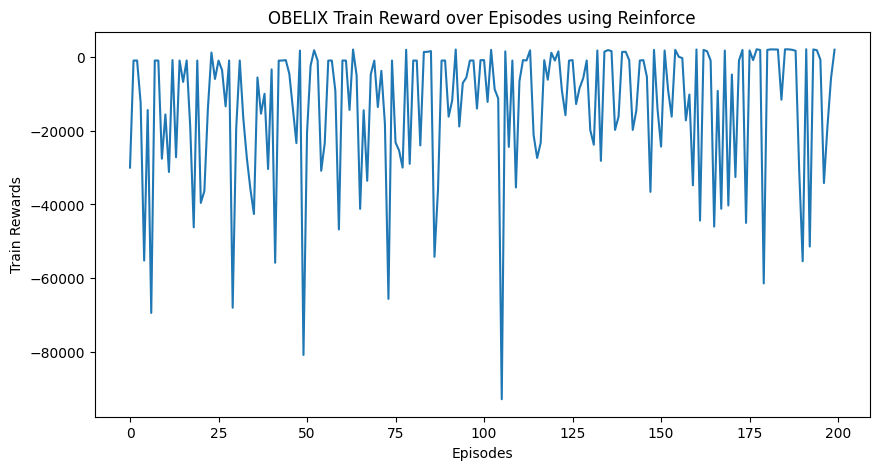

In [8]:
plotQuantity(
    ReinforceTrainRewardsList, 
    len(ReinforceTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using Reinforce"]    
)

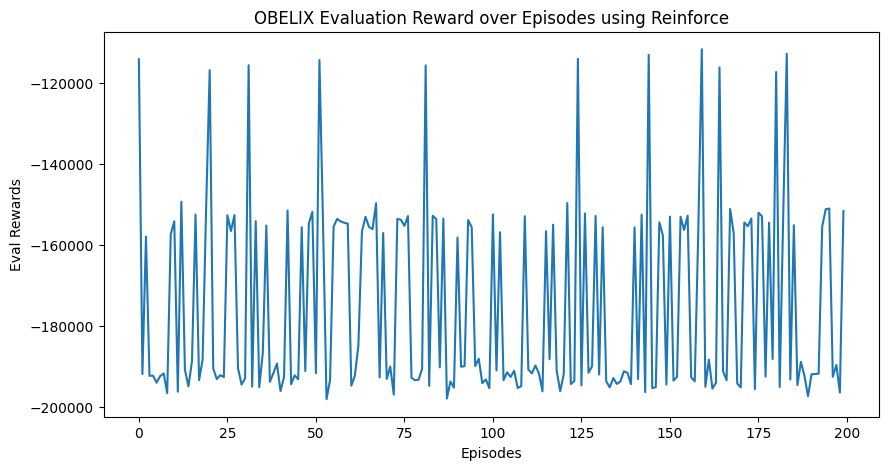

In [9]:
plotQuantity(
    ReinforceEvalRewardsList, 
    len(ReinforceEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using Reinforce"]    
)

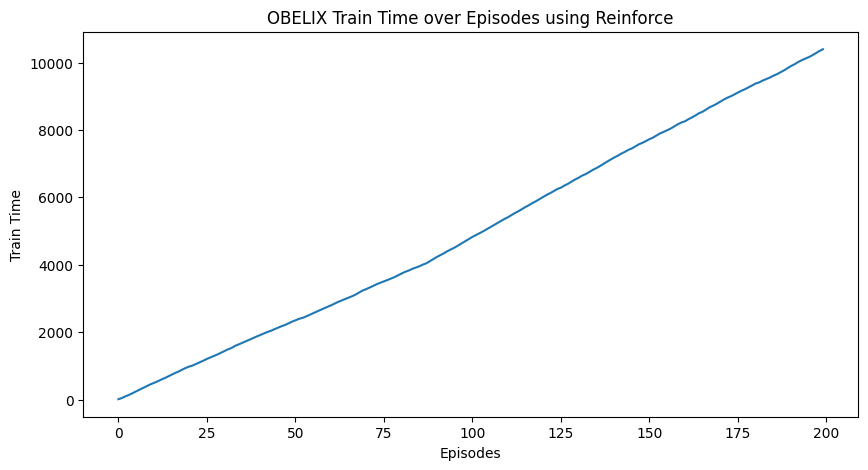

In [10]:
plotQuantity(
    ReinforceTrainTimeList, 
    len(ReinforceTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using Reinforce"]    
)

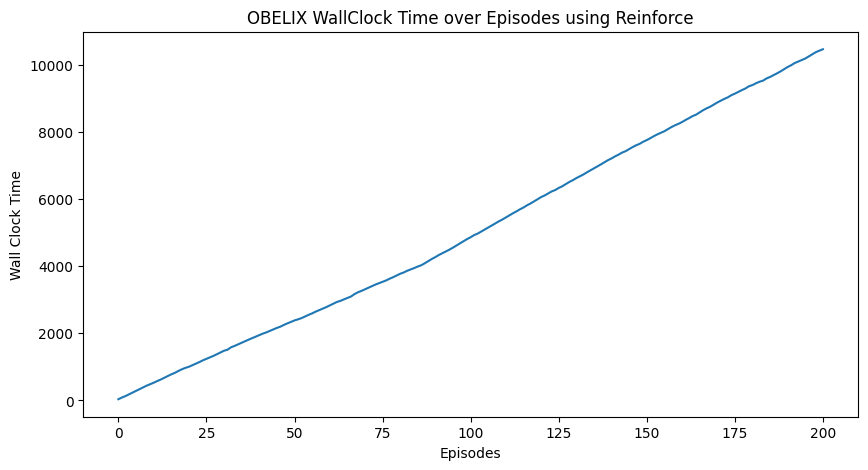

In [11]:
plotQuantity(
    ReinforceWallClockTimeList, 
    len(ReinforceWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using Reinforce"]    
)

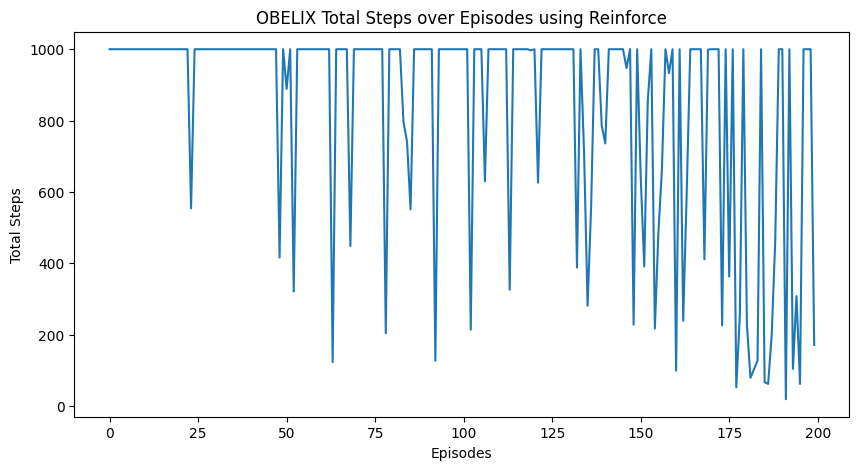

In [12]:
plotQuantity(
    ReinforceTotalStepsList, 
    len(ReinforceTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using Reinforce"]    
)